# Facial Detection with the Haar Cascade Classifier

In [14]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [15]:
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output
import os
import random
from PIL import Image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [16]:
data_dir_path = "/content/gdrive/My Drive/Masters/"
all_files = os.listdir(data_dir_path)
all_files

['matchpairsDevTest.csv',
 'matchpairsDevTrain.csv',
 'peopleDevTest.csv',
 'pairs.csv',
 'mismatchpairsDevTest.csv',
 'lfw_allnames.csv',
 'peopleDevTrain.csv',
 'mismatchpairsDevTrain.csv',
 'people_gender_race.csv',
 'lfw_attributes.csv',
 'lfw_attributes.txt',
 'people.csv',
 'EDA.ipynb',
 'sunglasses.png',
 'hat.png',
 'Serena_Williams_sg.png',
 'Serena_Williams_hat.png',
 'mask.png',
 'Data_Augmentation.ipynb',
 'Colin_Powell.csv',
 'Gerhard_Schroeder.csv',
 'Hugo_Chavez.csv',
 'Junichiro_Koizumi.csv',
 'Serena_Williams.csv',
 'Train',
 'Test',
 'DA',
 'DA_photos',
 'lfw-deepfunneled',
 'LFW_recognition.ipynb',
 'Face_Detection_LFW.ipynb',
 'Face_Detection.ipynb']

In [17]:
import pandas as pd

# Read metadata about the dataset
allNames = pd.read_csv("/content/gdrive/My Drive/Masters/lfw_allnames.csv")
# Display summary statistics of the number of images per person
allNames["images"].describe()

,images
count,5749.000000
mean,2.301792
std,9.016410
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,530.000000


In [18]:
# Define the path to the images directory
images_data_dir = os.path.join(data_dir_path, 'lfw-deepfunneled', 'lfw-deepfunneled')

In [19]:
# Get the list of persons (directories) in the images directory
persons = os.listdir(images_data_dir)
len(persons)

5749

In [20]:
random_person = np.random.choice(persons, 15, replace = False) # replace = False means no duplicate.
select_images = []
for person in random_person:
    person_dir = os.path.join(images_data_dir, person)
    person_file = os.listdir(person_dir)
    select_person_image_file = random.choice(person_file)
    select_images.append(os.path.join(person_dir, select_person_image_file))

select_images

['/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Sila_Calderon/Sila_Calderon_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Heather_Locklear/Heather_Locklear_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Brandon_Spann/Brandon_Spann_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Kevin_Harvick/Kevin_Harvick_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Ray_Bradbury/Ray_Bradbury_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Milan_Milutinovic/Milan_Milutinovic_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Steve_Kerr/Steve_Kerr_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Pamela_Melroy/Pamela_Melroy_0001.jpg',
 '/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/Aaron_Sorkin/Aaron_Sorkin_0002.jpg',
 '/content/gdrive/My Dri

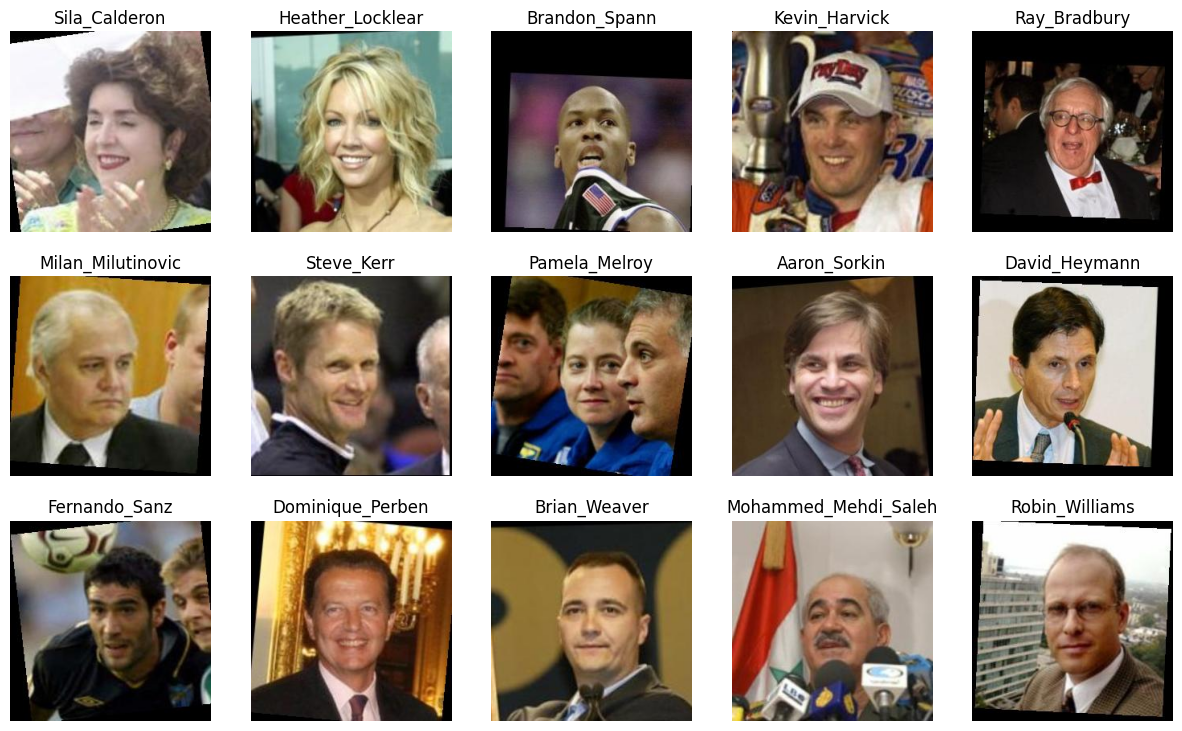

In [21]:
fig, axs = plt.subplots(3, 5, figsize = (15, 9))
for i, image_path in enumerate(select_images):
    img = mpimg.imread(image_path)
    axs[i // 5, i % 5].imshow(img)
    axs[i // 5, i % 5].set_title(select_images[i].split('/')[-2])
    axs[i // 5, i % 5].axis('off')

plt.show()

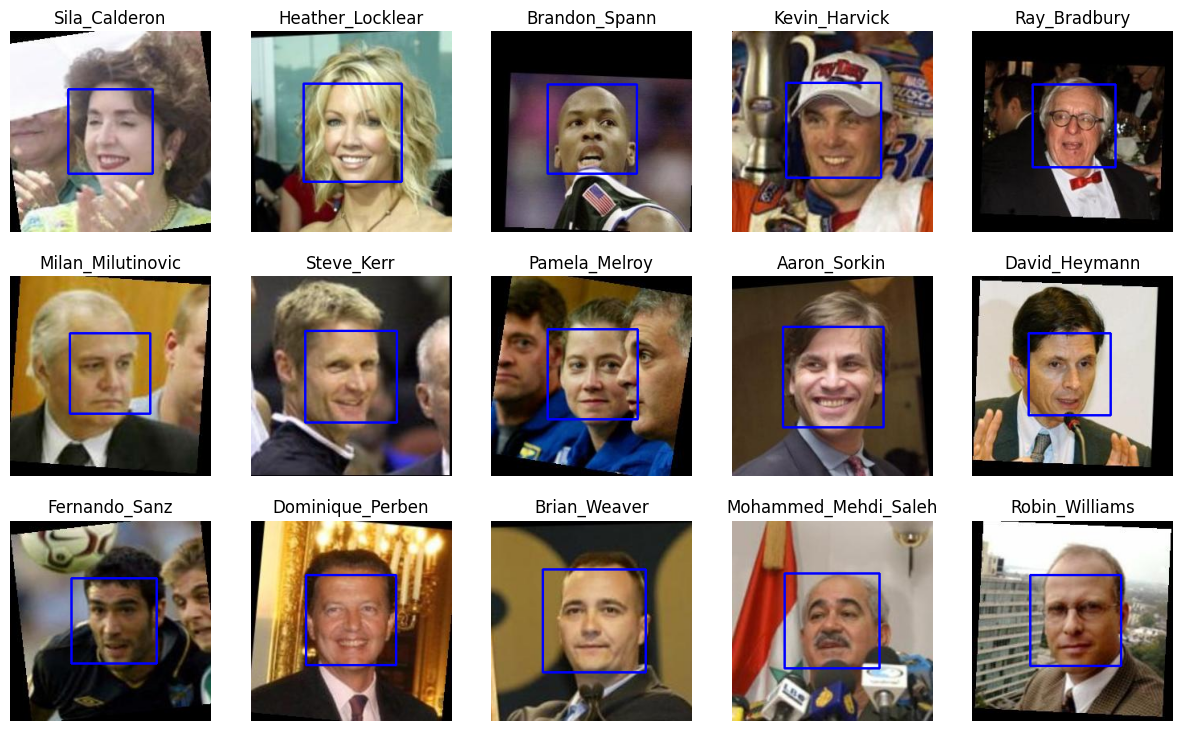

In [22]:
# Plotting images with bounding boxes
fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for i, image_path in enumerate(select_images):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

     # Detect faces in the image
    face_detect = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = face_detect.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw bounding boxes around detected faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    axs[i // 5, i % 5].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[i // 5, i % 5].set_title(image_path.split('/')[-2]) # Extract person's name from the path
    axs[i // 5, i % 5].axis('off')
    axs[i // 5, i % 5].axis('off')

plt.show()